In [1]:
# STANDIN A0
# Load the data, the split and the shared helpers (parts/00_setup.ipynb). Dropped from the hand-in
# notebook, where the setup cells come first.
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project
Data folder: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project/UNSW-NB15
score() and score_proba() ready


Rows with an infinite or missing value: 0
Loaded 447,915 flows x 76 features


Raw rows:                      447,915
Exact duplicates removed:      141,742
Conflicting rows removed:        1,068
Clean rows (all are used):     305,105


Dropped 9 constant columns: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, URG Flag Count, CWR Flag Count, ECE Flag Count, Fwd Bytes/Bulk Avg, Fwd Packet/Bulk Avg, Fwd Bulk Rate Avg
67 features: 65 continuous, 2 0/1 columns (Fwd PSH Flags, RST Flag Count)
TUNE_IDX: 36,612 training rows for settings searches
Model cache: models/d8137a9708 (0 saved results)
Setup complete: 23 shared names ready in 29 s


<!-- STEP A1 -->
## Part A: the security problem

**What is detected.** We build a network intrusion detector: for every network flow (one conversation
between two computers, summarised as 67 numbers about packet counts, sizes and timing) it decides whether
the flow is **normal traffic or part of an attack**, such as exploiting a software bug, fuzzing a service
with malformed data, scanning the network, a denial-of-service flood, a backdoor or a worm.

**Who uses it.** The analysts of a Security Operations Centre (SOC), who receive the detector's alerts
and must decide for each one whether to investigate, block the connection or ignore it.

**What a false alarm costs.** Every false alarm takes an analyst's time to check and dismiss. A network
sees millions of flows a day, so even a false alarm rate of 1% means about 10,000 false alarms per million
normal flows. Analysts then start ignoring alerts, and real attacks drown among the false ones (*alert
fatigue*). A **missed attack** costs more per case: the attacker gets in unnoticed and can steal data or
damage systems. The detector therefore has to catch most attacks (high recall) while keeping the false
alarm rate (FAR) low, and we report both.

**Data.** CIC-UNSW-NB15: the UNSW-NB15 traffic recorded in 2015 at UNSW Canberra (normal traffic plus
nine attack types), turned into flows by CICFlowMeter. After removing duplicates and conflicting rows we
use **all 305,105 clean flows** (26.3% attacks), with no subsample.

<!-- STEP A4 -->
## Part A: the trivial baseline

The simplest possible "detector" never raises an alarm: it calls **every flow benign**, the majority
class. It needs no learning, yet scores an accuracy equal to the share of benign flows (about 74%).
That is why accuracy alone says little here: **every model below must beat this line**, and the scores
that matter are the ones this baseline fails on:

- **recall = 0**: it catches no attack at all;
- **macro-F1 ≈ 0.42**: perfect-looking on the benign class, zero on the attack class;
- **PR-AUC = the attack share (≈ 0.26)**: what a model gets by guessing, since it gives every flow the
  same score;
- **FAR = 0**: it never raises a false alarm, but only because it never raises any alarm.

We score it on the validation set and on the test set.

In [2]:
# STEP A4
from sklearn.dummy import DummyClassifier

always_benign = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

baseline = pd.DataFrame({"validation": score(always_benign, X_val, y_val),
                         "test": score(always_benign, X_test, y_test)}).T
baseline.index.name = "set"

# The baseline must be exactly what the definitions say.
for part, y_part in (("validation", y_val), ("test", y_test)):
    row = baseline.loc[part]
    assert np.isclose(row["accuracy"], 1 - y_part.mean())          # = share of benign flows
    assert row["recall"] == 0 and row["far"] == 0
    assert np.isclose(row["pr_auc"], y_part.mean())                # = share of attacks

baseline.to_csv(TABLES / "A4_baseline.csv", float_format="%.4f")
print(f"Always benign, test set: accuracy {baseline.loc['test', 'accuracy']:.3f} "
      f"(= {int((y_test == 0).sum()):,} benign of {len(y_test):,} flows), recall 0, "
      f"macro-F1 {baseline.loc['test', 'macro_f1']:.3f}, PR-AUC {baseline.loc['test', 'pr_auc']:.3f}, FAR 0")
baseline.round(4)

Always benign, test set: accuracy 0.737 (= 44,969 benign of 61,021 flows), recall 0, macro-F1 0.424, PR-AUC 0.263, FAR 0


,accuracy,macro_f1,recall,pr_auc,far
set,,,,,
validation,0.7369,0.4243,0.0,0.2631,0.0
test,0.7369,0.4243,0.0,0.2631,0.0


<!-- STEP B1 -->
## Part B: glass boxes (models a person can read)

Two "glass box" models, whose decisions a person can follow:

- a **decision tree**: a chain of yes/no questions about the features ("is `Fwd Seg Size Min` above
  28?"), ending in "attack" or "benign";
- **logistic regression**: one weight per feature; the weighted sum of the (scaled) features gives the
  attack probability. A positive weight pushes towards "attack", a negative one towards "benign".

**How the settings are chosen.** Each candidate setting is trained on a stratified 20% part of the
training set (`TUNE_IDX`, 36,612 flows) and scored on the **validation** set; the best macro-F1 wins.
The chosen setting is then trained on the **whole** training set (183,063 flows). The test set is not
used here.

- Tree: the maximum depth (number of questions in a row), from `[3, 5, 8, 12, None]` (`None` = no
  limit). On a tie we keep the smaller tree, which is easier to read.
- Logistic regression: `C`, the inverse strength of the penalty that keeps weights small, from
  `[0.01, 0.1, 1, 10]`. The features are scaled to mean 0 and standard deviation 1 inside a `Pipeline`,
  so the scaler only ever learns from training rows.

In [3]:
# STEP B1
from sklearn.tree import DecisionTreeClassifier, export_text

X_tune, y_tune = X_train.iloc[TUNE_IDX], y_train.iloc[TUNE_IDX]

rows = []
for depth in [3, 5, 8, 12, None]:
    candidate = cached(f"B1_tree_depth{depth}_tune",
                       lambda: DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(X_tune, y_tune))
    rows.append({"max_depth": "none" if depth is None else depth, "leaves": candidate.get_n_leaves(),
                 **score(candidate, X_val, y_val)})
tree_search = pd.DataFrame(rows)
tree_search.to_csv(TABLES / "B1_tree_depth.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the smaller tree (the rows are in order of growing depth).
best = tree_search.loc[tree_search["macro_f1"].round(4).idxmax()]
TREE_DEPTH = None if best["max_depth"] == "none" else int(best["max_depth"])
tree = cached(f"B1_tree_depth{TREE_DEPTH}_all",
              lambda: DecisionTreeClassifier(max_depth=TREE_DEPTH, random_state=SEED).fit(X_train, y_train))

print(f"Chosen depth: {best['max_depth']} (validation macro-F1 on the 20% part: {best['macro_f1']:.4f})")
print(f"Final tree on all training rows: {tree.get_n_leaves():,} leaves, depth {tree.get_depth()}")
print("Validation scores of the final tree:",
      {k: round(v, 4) for k, v in score(tree, X_val, y_val).items()})
tree_search.round(4)

Chosen depth: 12 (validation macro-F1 on the 20% part: 0.9643)
Final tree on all training rows: 449 leaves, depth 12


Validation scores of the final tree: {'accuracy': 0.9751, 'macro_f1': 0.9685, 'recall': 0.9844, 'pr_auc': 0.965, 'far': 0.0282}


,max_depth,leaves,accuracy,macro_f1,recall,pr_auc,far
0,3,8,0.9697,0.9622,0.9967,0.9375,0.0399
1,5,22,0.9709,0.9635,0.9897,0.9509,0.0358
2,8,82,0.9715,0.9641,0.9837,0.9546,0.0329
3,12,287,0.9718,0.9643,0.9738,0.9461,0.0289
4,none,1017,0.9600,0.9482,0.9194,0.8742,0.0256


In [4]:
# STEP B1
# The first three levels of questions of the final tree.
print(export_text(tree, feature_names=FEATURES, max_depth=3, decimals=1))

|--- FWD Init Win Bytes <= 16368.5
|   |--- Bwd Packets/s <= 0.0
|   |   |--- Fwd Seg Size Min <= 16.0
|   |   |   |--- Subflow Fwd Bytes <= 148.0
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- Subflow Fwd Bytes >  148.0
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- Fwd Seg Size Min >  16.0
|   |   |   |--- class: 0
|   |--- Bwd Packets/s >  0.0
|   |   |--- Bwd Packet Length Min <= 61.5
|   |   |   |--- Down/Up Ratio <= 201.5
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- Down/Up Ratio >  201.5
|   |   |   |   |--- class: 1
|   |   |--- Bwd Packet Length Min >  61.5
|   |   |   |--- ACK Flag Count <= 2.5
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- ACK Flag Count >  2.5
|   |   |   |   |--- class: 0
|--- FWD Init Win Bytes >  16368.5
|   |--- FWD Init Win Bytes <= 16406.5
|   |   |--- Packet Length Max <= 54.5
|   |   |   |--- Fwd IAT Std <= 36469.7
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |

In [5]:
# STEP B1
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def make_logreg(C):
    """Logistic regression with scaling inside the model, so it can be given raw features."""
    return Pipeline([("scale", StandardScaler()),
                     ("model", LogisticRegression(C=C, max_iter=2000, random_state=SEED))])


def fit_logreg(C, X, y):
    """Train make_logreg(C) on (X, y); returns the model and whether it converged."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        model = make_logreg(C).fit(X, y)
    return model, not any(issubclass(w.category, ConvergenceWarning) for w in caught)


rows = []
for C in [0.01, 0.1, 1, 10]:
    candidate, converged = cached(f"B1_logreg_C{C}_tune", lambda: fit_logreg(C, X_tune, y_tune))
    rows.append({"C": C, "converged": converged, "iterations": int(candidate[-1].n_iter_[0]),
                 **score(candidate, X_val, y_val)})
logreg_search = pd.DataFrame(rows)
logreg_search.to_csv(TABLES / "B1_logreg_C.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the smaller C (stronger penalty, simpler model).
LOGREG_C = float(logreg_search.loc[logreg_search["macro_f1"].round(4).idxmax(), "C"])
logreg, logreg_converged = cached(f"B1_logreg_C{LOGREG_C}_all", lambda: fit_logreg(LOGREG_C, X_train, y_train))

print(f"Chosen C: {LOGREG_C}; final model on all training rows converged: {logreg_converged} "
      f"({int(logreg[-1].n_iter_[0])} iterations)")
print("Validation scores of the final logistic regression:",
      {k: round(v, 4) for k, v in score(logreg, X_val, y_val).items()})
logreg_search.round(4)

Chosen C: 10.0; final model on all training rows converged: True (450 iterations)


Validation scores of the final logistic regression: {'accuracy': 0.9686, 'macro_f1': 0.9608, 'recall': 0.9965, 'pr_auc': 0.95, 'far': 0.0414}


,C,converged,iterations,accuracy,macro_f1,recall,pr_auc,far
0,0.01,True,34,0.9663,0.9580,0.9923,0.9315,0.0430
1,0.10,True,70,0.9675,0.9595,0.9944,0.9370,0.0421
2,1.00,True,143,0.9680,0.9602,0.9966,0.9411,0.0422
3,10.00,True,241,0.9681,0.9603,0.9961,0.9448,0.0419


In [6]:
# STEP B1
# The 10 largest weights. The features were scaled, so the weights are comparable: a weight of +2
# means "one standard deviation more of this feature adds 2 to the log-odds of attack".
weights = pd.Series(logreg[-1].coef_[0], index=FEATURES)
top_weights = weights.reindex(weights.abs().sort_values(ascending=False).index).head(10)
weights_table = pd.DataFrame({"weight": top_weights,
                              "pushes towards": np.where(top_weights > 0, "attack", "benign")})
weights_table.index.name = "feature"
weights_table.to_csv(TABLES / "B1_logreg_weights.csv", float_format="%.4f")
weights_table.round(3)

,weight,pushes towards
feature,,
ACK Flag Count,18.510,attack
Flow Duration,14.533,attack
Fwd IAT Total,-14.427,benign
PSH Flag Count,-12.727,benign
Bwd Packets/s,-10.074,benign
Total Bwd packets,9.007,attack
Bwd Header Length,-8.562,benign
Total Length of Bwd Packet,-6.985,benign
Fwd Header Length,-6.267,benign


<!-- STEP B1 -->
### What the glass boxes show

**Decision tree.** Depth 12 has the best validation macro-F1 (0.9643 on the 20% part), but only
0.0002 above depth 8, with 287 instead of 82 leaves. We keep the rule fixed in advance (best validation
score wins), so the final tree has depth 12 (449 leaves when trained on all training rows); a security
team that values readability could reasonably pick depth 8 instead. Without a depth limit the tree
overfits: its validation recall falls to 0.919. The final tree reaches a validation macro-F1 of 0.9685,
recall 0.984 and FAR 0.028, far above the always-benign baseline (macro-F1 0.424, recall 0).

**The tree's first question** is "is `FWD Init Win Bytes` at most 16,368?": the TCP window size that the
initiating machine announces when it opens the connection. This is a setting of the machine's operating
system, not something an attack *does*. The tree is partly recognising the attacker's machines (all
UNSW-NB15 attacks come from a few of them), a shortcut that Part D examines with SHAP.

**Logistic regression.** All four values of `C` give almost the same validation macro-F1 (0.958 to
0.960); `C = 10` is highest. It catches slightly more attacks than the tree (validation recall 0.997)
but raises more false alarms (FAR 0.041). Its largest weights must be read with care: `Flow Duration`
(+14.5) and `Fwd IAT Total` (−14.4) are near-copies of each other (twin group 1 in the feature glossary,
correlation above 0.95), so their large opposite weights mostly cancel out. With correlated features,
the size and even the sign of a single weight say little on their own.

<!-- STEP B2 -->
## Part B: the black box (gradient boosting)

The black box is **gradient boosting** (scikit-learn's `HistGradientBoostingClassifier`): a sequence of
small decision trees, each one trained to fix the mistakes of the trees before it. The final answer adds
up the votes of all trees. Together they are far too many questions for a person to follow, which makes
it a black box; Part D explains it with SHAP and LIME.

**Why not a random forest?** The brief allows "random forest or gradient boosting". On all 183,063
training flows a forest of 300 trees took about 8 minutes to train, and SHAP on 300 flows took over
12 minutes in a trial, against seconds for gradient boosting. Every later part retrains or explains the
black box many times, so gradient boosting is the practical choice for the full dataset.

**How the settings are chosen.** As in B1: each candidate is trained on the 20% part of the training set
and scored on the validation set; the best macro-F1 wins and is trained on the whole training set. We try
two settings that control how the model learns:

- `learning_rate` in `[0.05, 0.1]`: how big a correction each new tree makes;
- `max_leaf_nodes` in `[31, 63]`: how many end points (leaves) each small tree may have.

Gradient boosting stops adding trees by itself when they stop helping (*early stopping*): it keeps 10%
of the rows it is given aside and watches the score on them. Those rows come from the data the model is
trained on, never from our validation or test set.

The chosen settings are published as `BOOST_SETTINGS`, with `make_boost()` to build a fresh, untrained
copy. Parts C, F and G use them, so every part works with the same black box.

In [7]:
# STEP B2
from sklearn.ensemble import HistGradientBoostingClassifier

rows = []
for learning_rate in [0.05, 0.1]:
    for max_leaf_nodes in [31, 63]:
        settings = {"learning_rate": learning_rate, "max_leaf_nodes": max_leaf_nodes,
                    "random_state": SEED}
        candidate = cached(f"B2_boost_lr{learning_rate}_leaves{max_leaf_nodes}_tune",
                           lambda: HistGradientBoostingClassifier(**settings).fit(X_tune, y_tune))
        rows.append({"learning_rate": learning_rate, "max_leaf_nodes": max_leaf_nodes,
                     "trees": candidate.n_iter_, **score(candidate, X_val, y_val)})
boost_search = pd.DataFrame(rows)
boost_search.to_csv(TABLES / "B2_boost_grid.csv", index=False, float_format="%.4f")

# Best validation macro-F1; on a tie the first row (smaller learning rate, smaller trees).
best = boost_search.loc[boost_search["macro_f1"].round(4).idxmax()]
BOOST_SETTINGS = {"learning_rate": float(best["learning_rate"]),
                  "max_leaf_nodes": int(best["max_leaf_nodes"]), "random_state": SEED}
BOOST_TAG = f"lr{BOOST_SETTINGS['learning_rate']}_leaves{BOOST_SETTINGS['max_leaf_nodes']}"   # for cache names


def make_boost():
    """A new, untrained gradient boosting model with the settings chosen on validation."""
    return HistGradientBoostingClassifier(**BOOST_SETTINGS)


boost = cached(f"B2_boost_{BOOST_TAG}_all", lambda: make_boost().fit(X_train, y_train))
MODELS = {"tree": tree, "logreg": logreg, "boosting": boost}

print(f"Chosen settings: {BOOST_SETTINGS}")
print(f"Final model on all training rows: {boost.n_iter_} trees")
print("Validation scores of the final model:",
      {k: round(v, 4) for k, v in score(boost, X_val, y_val).items()})
boost_search.round(4)

Chosen settings: {'learning_rate': 0.1, 'max_leaf_nodes': 31, 'random_state': 42}
Final model on all training rows: 100 trees


Validation scores of the final model: {'accuracy': 0.9772, 'macro_f1': 0.9713, 'recall': 0.9924, 'pr_auc': 0.9807, 'far': 0.0282}


,learning_rate,max_leaf_nodes,trees,accuracy,macro_f1,recall,pr_auc,far
0,0.05,31,100,0.9756,0.9693,0.9910,0.9766,0.0299
1,0.05,63,100,0.9756,0.9692,0.9882,0.9761,0.0289
2,0.10,31,71,0.9762,0.9700,0.9907,0.9768,0.0290
3,0.10,63,71,0.9756,0.9691,0.9864,0.9756,0.0283


<!-- STEP B2 -->
### What the black box shows

All four settings score within 0.001 of each other on validation (macro-F1 0.969 to 0.970), so the
choice hardly matters; `learning_rate = 0.1` with `max_leaf_nodes = 31` is best (these are also
scikit-learn's defaults). Trained on all training rows, gradient boosting reaches a validation
**macro-F1 of 0.9713, recall 0.992, PR-AUC 0.981 and FAR 0.028**: the best of the three models on
macro-F1 and PR-AUC, with the recall of logistic regression and the false alarm rate of the tree.

The margin over the glass boxes is small (macro-F1 +0.003 over the tree, +0.011 over logistic regression).
On this dataset the black box buys little accuracy; the question in Part D is whether it at least looks at
sensible evidence.

The final model used all **100 trees** it is allowed (`max_iter = 100`, the default): early stopping did
not stop it, so it might gain a little from more trees. We did not search the number of trees; that is a
possible extra check.

<!-- STEP B3 -->
## Part B: scores on the test set, next to the trivial baseline

All settings are now fixed (B1, B2), so the models are scored on the **test set** for the first time.
Nothing below changes a model or a setting. The same table on the validation set is shown first, so
the two can be compared: if a model scored much worse on test than on validation, the settings would
have been tuned too closely to the validation set.

The four scores the brief asks for are macro-F1, recall, PR-AUC and FAR (false alarm rate); accuracy is
shown because the always-benign baseline is defined by it.

In [8]:
# STEP B3
def scores_table(X, y):
    """The always-benign baseline and the three Part B models, scored on (X, y)."""
    rows = {"always benign": score(always_benign, X, y)}
    rows.update({name: score(model, X, y) for name, model in MODELS.items()})
    table = pd.DataFrame(rows).T[["macro_f1", "recall", "pr_auc", "far", "accuracy"]]
    table.index.name = "model"
    return table


val_scores = scores_table(X_val, y_val)
test_scores = scores_table(X_test, y_test)
val_scores.to_csv(TABLES / "B3_val_scores.csv", float_format="%.4f")
test_scores.to_csv(TABLES / "B3_test_scores.csv", float_format="%.4f")

print("Validation set")
print(val_scores.round(4).to_string())
print("\nTest set")
print(test_scores.round(4).to_string())
print("\nTest minus validation (a large drop would mean the settings were tuned too closely to validation)")
print((test_scores - val_scores).round(4).to_string())

Validation set
               macro_f1  recall  pr_auc     far  accuracy
model                                                    
always benign    0.4243  0.0000  0.2631  0.0000    0.7369
tree             0.9685  0.9844  0.9650  0.0282    0.9751
logreg           0.9608  0.9965  0.9500  0.0414    0.9686
boosting         0.9713  0.9924  0.9807  0.0282    0.9772

Test set
               macro_f1  recall  pr_auc     far  accuracy
model                                                    
always benign    0.4243  0.0000  0.2631  0.0000    0.7369
tree             0.9690  0.9849  0.9677  0.0279    0.9755
logreg           0.9608  0.9962  0.9527  0.0413    0.9686
boosting         0.9718  0.9923  0.9814  0.0276    0.9776

Test minus validation (a large drop would mean the settings were tuned too closely to validation)
               macro_f1  recall  pr_auc     far  accuracy
model                                                    
always benign    0.0000  0.0000  0.0000  0.0000    0.0000
tree  

<!-- STEP B3 -->
### What the test scores show

| Model (test set) | Macro-F1 | Recall | PR-AUC | FAR |
|---|---|---|---|---|
| Always benign | 0.424 | 0 | 0.263 | 0 |
| Decision tree | 0.969 | 0.985 | 0.968 | 0.028 |
| Logistic regression | 0.961 | 0.996 | 0.953 | 0.041 |
| Gradient boosting | **0.972** | 0.992 | **0.981** | **0.028** |

**All three models are far above the trivial baseline**: they catch 98–99.6% of the attacks, where the
baseline catches none, and their macro-F1 is more than twice the baseline's 0.424.

**Test and validation agree** to within 0.003 on every score. The settings chosen on validation were not
tuned too closely to it, and the test scores are a fair estimate for flows like these.

**Gradient boosting is the best model overall**, but only just: 0.003 macro-F1 above the decision tree.
Logistic regression catches the most attacks (recall 0.996) but pays with the most false alarms (FAR
0.041, against 0.028).

**What these numbers mean in practice.** On the 61,021 test flows, gradient boosting misses about 1 in
130 attacks (about 124 of 16,052) and raises a false alarm on about 1 in 36 benign flows (about 1,240 of
44,969). In real traffic benign flows are far more common than in this dataset (about 97.5% instead of
74%), so the same FAR would produce many more false alarms per real attack caught; step B4 puts a number
on this.

<!-- STEP B4 -->
## Part B: where the models go wrong

A single recall of 0.99 hides *which* attacks are missed, and a false alarm rate of 0.03 hides how many
alarms that means in a real network. Three views of the test-set mistakes:

1. **Confusion matrices**: for each model, how many benign flows and attacks were called benign or
   attack. Each cell shows the count and its share of the row (the true class).
2. **Recall per attack type**: which kinds of attack slip through. Attack types with fewer than 100 test
   flows (Backdoor, Analysis, Worms) give less precise numbers: one flow more or less moves their recall
   by 1–2 points.
3. **False alarms per day**: the test-set scores applied to a network with realistic traffic, where
   only about 2.5% of flows are attacks (in the full UNSW-NB15 recording, 89,583 of 3,540,241 flows),
   not 26% as in our dataset.

The figures use one colour and one marker shape per model, the same in every figure of this project:
gradient boosting blue circles, decision tree orange squares, logistic regression aqua triangles.

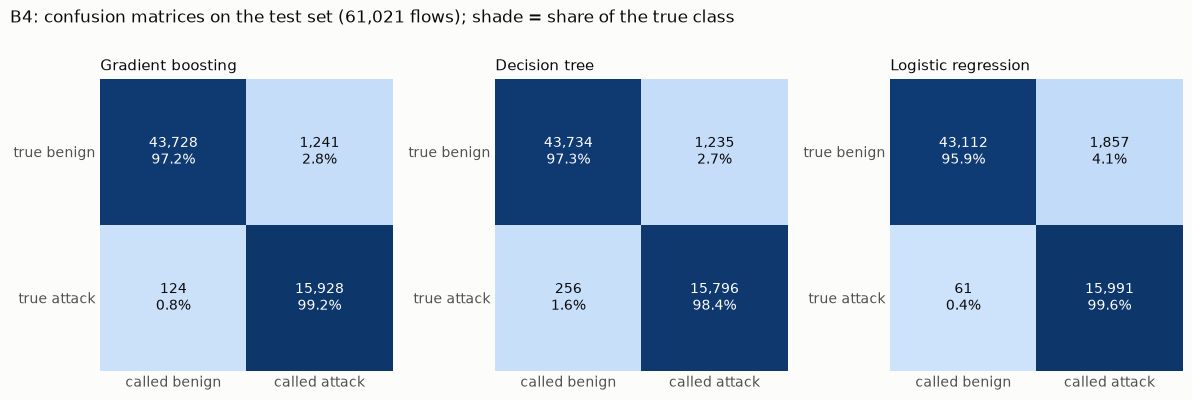

,true_benign_called_benign,true_benign_called_attack,true_attack_called_benign,true_attack_called_attack
model,,,,
boosting,43728,1241,124,15928
tree,43734,1235,256,15796
logreg,43112,1857,61,15991


In [9]:
# STEP B4
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Figure style for the whole project: one colour and marker per model (validated colour-blind-safe set),
# text in ink colours, light grid, no box around the plot.
MODEL_LABELS = {"boosting": "Gradient boosting", "tree": "Decision tree", "logreg": "Logistic regression"}
MODEL_COLORS = {"boosting": "#2a78d6", "tree": "#eb6834", "logreg": "#1baf7a"}
MODEL_MARKERS = {"boosting": "o", "tree": "s", "logreg": "^"}
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blue_ramp", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def style_axes(ax, grid_axis="y"):
    ax.set_facecolor(SURFACE)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK_2)


ORDER = ["boosting", "tree", "logreg"]
test_pred = {name: MODELS[name].predict(X_test) for name in ORDER}

# 1. Confusion matrices on the test set.
rows = []
for name in ORDER:
    tn, fp, fn, tp = confusion_matrix(y_test, test_pred[name], labels=[0, 1]).ravel()
    rows.append({"model": name, "true_benign_called_benign": tn, "true_benign_called_attack": fp,
                 "true_attack_called_benign": fn, "true_attack_called_attack": tp})
confusion = pd.DataFrame(rows).set_index("model")
confusion.to_csv(TABLES / "B4_confusion.csv")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), facecolor=SURFACE)
for ax, name in zip(axes, ORDER):
    r = confusion.loc[name]
    counts = np.array([[r.true_benign_called_benign, r.true_benign_called_attack],
                       [r.true_attack_called_benign, r.true_attack_called_attack]])
    share = counts / counts.sum(axis=1, keepdims=True)
    ax.imshow(share, cmap=BLUE_RAMP, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{counts[i, j]:,}\n{share[i, j]:.1%}", ha="center", va="center", fontsize=10,
                    color="white" if share[i, j] > 0.5 else INK)
    ax.set_xticks([0, 1], ["called benign", "called attack"])
    ax.set_yticks([0, 1], ["true benign", "true attack"])
    ax.tick_params(length=0, labelcolor=INK_2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(MODEL_LABELS[name], color=INK, fontsize=11, loc="left")
fig.suptitle("B4: confusion matrices on the test set (61,021 flows); shade = share of the true class",
             color=INK, x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURES / "B4_confusion.png", dpi=150, facecolor=SURFACE)
plt.show()
confusion

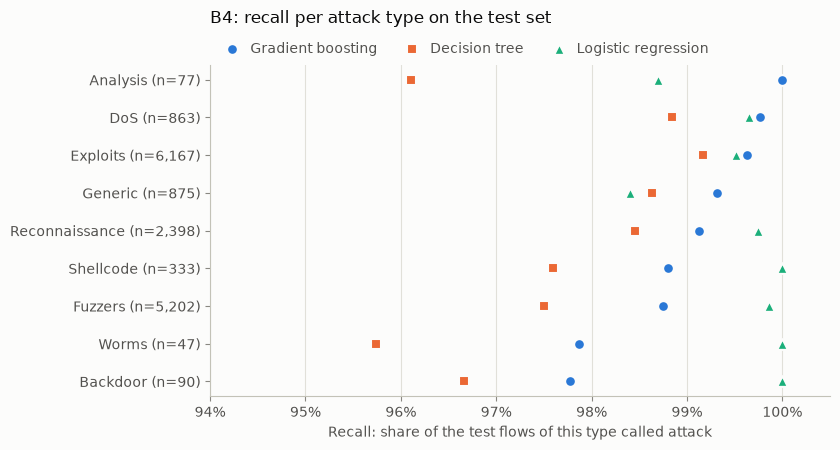

,test_flows,boosting,tree,logreg,note
attack_type,,,,,
Backdoor,90,0.9778,0.9667,1.0000,few flows: less precise
Worms,47,0.9787,0.9574,1.0000,few flows: less precise
Fuzzers,5202,0.9875,0.9750,0.9987,
Shellcode,333,0.9880,0.9760,1.0000,
Reconnaissance,2398,0.9912,0.9846,0.9975,
Generic,875,0.9931,0.9863,0.9840,
Exploits,6167,0.9963,0.9917,0.9951,
DoS,863,0.9977,0.9884,0.9965,
Analysis,77,1.0000,0.9610,0.9870,few flows: less precise


In [10]:
# STEP B4
# 2. Recall per attack type on the test set (benign row: share wrongly called attack = FAR).
rows = []
for attack in type_test.unique():
    mask = (type_test == attack).to_numpy()
    row = {"attack_type": attack, "test_flows": int(mask.sum())}
    for name in ORDER:
        row[name] = float(test_pred[name][mask].mean())     # share called "attack"
    rows.append(row)
per_type = pd.DataFrame(rows).set_index("attack_type")
per_type["note"] = np.where(per_type.index == "Benign", "share called attack = FAR",
                            np.where(per_type["test_flows"] < 100, "few flows: less precise", ""))
attacks = per_type.drop(index="Benign").sort_values("boosting")
per_type = pd.concat([attacks, per_type.loc[["Benign"]]])
per_type.to_csv(TABLES / "B4_recall_per_type.csv", float_format="%.4f")

# Dot plot: one row per attack type, one marker per model (worst-detected type at the bottom).
fig, ax = plt.subplots(figsize=(8.5, 4.6), facecolor=SURFACE)
style_axes(ax, grid_axis="x")
ypos = np.arange(len(attacks))
for name in ORDER:
    ax.scatter(attacks[name], ypos, s=60, marker=MODEL_MARKERS[name], color=MODEL_COLORS[name],
               edgecolor=SURFACE, linewidth=1.5, label=MODEL_LABELS[name], zorder=3)
ax.set_yticks(ypos, [f"{t} (n={n:,})" for t, n in zip(attacks.index, attacks["test_flows"])])
low = np.floor(attacks[ORDER].min().min() * 20) / 20
ax.set_xlim(low - 0.01, 1.005)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Recall: share of the test flows of this type called attack", color=INK_2)
ax.set_title("B4: recall per attack type on the test set", color=INK, loc="left", fontsize=12, pad=30)
# Legend in one row between the title and the plot, so it never covers a marker.
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3, frameon=False, labelcolor=INK_2,
          handletextpad=0.3, columnspacing=1.5, borderaxespad=0.2)
fig.tight_layout()
fig.savefig(FIGURES / "B4_recall_per_type.png", dpi=150, facecolor=SURFACE)
plt.show()
per_type.round(4)

In [11]:
# STEP B4
# 3. False alarms per day in a network with realistic traffic. In the full UNSW-NB15 recording
#    (CICFlowMeter_out.csv) 89,583 of 3,540,241 flows are attacks; our dataset keeps only ~10% of the
#    benign flows. We assume the same attack-type mix as in the test set.
REAL_ATTACK_SHARE = 89_583 / 3_540_241
FLOWS_PER_DAY = 1_000_000

rows = []
for name in ORDER:
    s = score(MODELS[name], X_test, y_test)
    attacks_per_day = FLOWS_PER_DAY * REAL_ATTACK_SHARE
    benign_per_day = FLOWS_PER_DAY - attacks_per_day
    caught = s["recall"] * attacks_per_day
    false_alarms = s["far"] * benign_per_day
    tp, fp = confusion.loc[name, "true_attack_called_attack"], confusion.loc[name, "true_benign_called_attack"]
    rows.append({"model": name, "recall": s["recall"], "far": s["far"],
                 "attacks_per_day": attacks_per_day, "caught_per_day": caught,
                 "missed_per_day": attacks_per_day - caught, "false_alarms_per_day": false_alarms,
                 "precision_test_set": tp / (tp + fp),
                 "precision_real_traffic": caught / (caught + false_alarms)})
alarms = pd.DataFrame(rows).set_index("model")
alarms.to_csv(TABLES / "B4_alarms_per_day.csv", float_format="%.4f")

print(f"Real traffic: {REAL_ATTACK_SHARE:.2%} attacks; {FLOWS_PER_DAY:,} flows per day")
alarms.style.format({"recall": "{:.4f}", "far": "{:.4f}", "attacks_per_day": "{:,.0f}",
                     "caught_per_day": "{:,.0f}", "missed_per_day": "{:,.0f}",
                     "false_alarms_per_day": "{:,.0f}", "precision_test_set": "{:.1%}",
                     "precision_real_traffic": "{:.1%}"})

Real traffic: 2.53% attacks; 1,000,000 flows per day


,recall,far,attacks_per_day,caught_per_day,missed_per_day,false_alarms_per_day,precision_test_set,precision_real_traffic
model,,,,,,,,
boosting,0.9923,0.0276,"25,304","25,109",195,"26,898",92.8%,48.3%
tree,0.9849,0.0279,"25,304","24,921",383,"27,180",92.7%,47.8%
logreg,0.9962,0.0413,"25,304","25,208",96,"40,250",89.6%,38.5%


<!-- STEP B4 -->
### What the mistakes show

**Confusion matrices.** On the 61,021 test flows, gradient boosting misses 124 attacks and raises 1,241
false alarms. The decision tree raises about as many false alarms (1,235) but misses twice as many
attacks (256). Logistic regression misses only 61 attacks but pays with 1,857 false alarms (50% more).
The models trade missed attacks against false alarms; none is best on both.

**Recall per attack type.** Every model catches at least 95.7% of every attack type. For gradient
boosting the weakest types are Backdoor (97.8%) and Worms (97.9%), but with only 90 and 47 test flows
these numbers move by 1–2 points per flow, so they are not precise. Among the large types, **Fuzzers**
is the weakest (98.75% of 5,202 flows): with about 65 missed flows it accounts for about half of all
attacks gradient boosting misses. Fuzzing sends random or malformed data, which can look much like
ordinary traffic; Part G returns to Fuzzers. Logistic regression reaches 100% on Backdoor, Worms and
Shellcode, but it calls more of everything an attack, which is also why its FAR is highest.

**False alarms per day in realistic traffic.** In the full UNSW-NB15 recording only 2.53% of flows are
attacks. Applied to a network with 1,000,000 flows a day (about 25,300 attacks), gradient boosting would
catch about 25,100 attacks and miss about 195, but also raise **about 26,900 false alarms**. Then only
**48% of its alerts would be real attacks**, against 93% on our test set, where attacks are ten times
more common. For logistic regression only 39% of alerts would be real. The test-set scores therefore
flatter the models: in a real SOC, more than half of the alerts would be false, which is exactly the
alert fatigue described in Part A. Lowering the FAR matters more than raising recall further. (This
estimate assumes the same mix of attack types and the same FAR as on the test set, and one alert per
flow; real systems group related alerts.)